# 단계 4 — 모델 3종 비교 (층화 5-fold 교차검증)

## 비교하는 모델

| 모델 | 입력 | 특징 |
|---|---|---|
| **로지스틱회귀** | WoE 변환값 | 신용평가 표준. 계수를 그대로 해석할 수 있어 "왜 그렇게 판단했는지" 설명이 쉽다 |
| **LightGBM** | 원본 값 | 표 형식 데이터에서 성능이 가장 좋은 편인 부스팅 모델 |
| **랜덤포레스트** | 원본 값 | 결정트리 여러 개의 다수결. 튼튼하고 과적합에 강하다 |

트리 계열(LightGBM·랜덤포레스트)은 "값이 X보다 큰가?"로 데이터를 나누기 때문에
스케일 변환이 필요 없습니다. 그래서 원본 값을 그대로 넣습니다.

---

## 평가 지표 — 왜 정확도(accuracy)를 안 쓰는가

사기 비율이 22%이므로, 무조건 "정상"이라고만 답해도 **정확도 78%** 가 나옵니다.
아무것도 못 잡았는데 성적표는 좋아 보이죠. 그래서 아래 세 지표를 씁니다.

### AUC (ROC 곡선 아래 면적)

> 무작위로 사기 주소 1개와 정상 주소 1개를 뽑았을 때,
> **모델이 사기 쪽에 더 높은 점수를 줄 확률**

- 0.5 = 동전 던지기 (전혀 구분 못 함)
- 1.0 = 완벽한 구분
- 임계값과 무관합니다. 순위만 맞으면 됩니다.

### KS (Kolmogorov-Smirnov 통계량)

$$\mathrm{KS} = \max_t \bigl| \mathrm{TPR}(t) - \mathrm{FPR}(t) \bigr|$$

**기호 뜻**

| 기호 | 뜻 |
|---|---|
| $t$ | 임계값. "점수가 $t$ 를 넘으면 사기로 판정" |
| $\mathrm{TPR}(t)$ | True Positive Rate. **진짜 사기 중** 사기라고 맞힌 비율 (= 재현율) |
| $\mathrm{FPR}(t)$ | False Positive Rate. **진짜 정상 중** 사기라고 잘못 찍은 비율 |
| $\max_t$ | 모든 임계값 중 가장 큰 값을 고른다 |

즉 **"사기는 많이 잡으면서 정상은 적게 건드리는 지점"의 최대 격차**입니다.
신용평가 실무에서 KS 0.3~0.5면 쓸 만한 모형으로 봅니다.

> **AUC 와 KS 의 차이**: AUC 는 모든 임계값 성능의 '평균',
> KS 는 '가장 잘 갈리는 한 지점'의 성능입니다.
> KS 가 최대가 되는 지점은 임계값 후보로도 자주 쓰입니다 (단계 6 참고).

### F1 (사기 클래스 기준)

$$\mathrm{F1} = 2 \times \frac{\text{정밀도} \times \text{재현율}}{\text{정밀도} + \text{재현율}}$$

| 기호 | 뜻 | 실패했을 때 |
|---|---|---|
| 정밀도 (precision) | 사기라고 찍은 것 중 **진짜 사기의 비율** | 헛다리를 짚어 정상 고객이 막힌다 |
| 재현율 (recall) | 진짜 사기 중 **잡아낸 비율** | 사기를 놓쳐 피해가 발생한다 |

둘의 **조화평균**이라 한쪽만 높으면 F1 은 커지지 않습니다.
F1 은 판정이 필요하므로 임계값이 있어야 합니다. 여기서는 **0.5**를 씁니다
(단계 6에서 비용에 맞게 다시 고릅니다).

---

## 교차검증 설계에서 반드시 지킨 것 2가지

**1. `shuffle=True`** — 단계 2에서 원본 CSV 의 앞 7,000행이 전부 정상,
8,000행 이후가 전부 사기인 것을 확인했습니다. 안 섞으면 어떤 fold 는
정상만, 어떤 fold 는 사기만 갖게 되어 평가 자체가 불가능합니다.

**2. WoE 는 학습 fold 안에서만 `fit`** — WoE 계산에는 정답이 들어갑니다.
전체 데이터로 미리 계산해 두면 검증 fold 의 정답이 학습에 새어 들어가
성능이 부풀려집니다.

In [1]:
import sys, time
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config, preprocessing, modeling
from src.plot_style import apply_project_plot_style, TRACK_COLORS, COLOR_TEXT_SECONDARY

apply_project_plot_style()
pd.set_option("display.width", 250)
config.ensure_directories_exist()

METRIC_COLUMNS = ["AUC", "KS", "F1(사기)", "정밀도(사기)", "재현율(사기)"]
print(f"난수 시드 = {config.RANDOM_SEED}, fold 수 = {config.CROSS_VALIDATION_FOLDS}")

난수 시드 = 42, fold 수 = 5


---

## 1. 두 트랙 비교

같은 모델·같은 교차검증 설정으로 **누수 포함(full)** 과 **누수 최소 차단(no_leak)** 을
나란히 돌립니다. 두 결과의 차이가 곧 **누수가 성능을 부풀린 정도**입니다.

In [2]:
# 두 트랙 모두 돌린다 (모델 3개 x fold 5개 x 트랙 2개 = 30번 학습)
track_summaries = {}
track_details = {}

for track_name in [preprocessing.TRACK_FULL, preprocessing.TRACK_NO_LEAK]:
    features, target, _ = preprocessing.build_modeling_dataset(track_name)

    start_time = time.time()
    summary_table, detailed_table = modeling.compare_all_models(features, target)
    elapsed_seconds = time.time() - start_time

    track_summaries[track_name] = summary_table
    track_details[track_name] = detailed_table
    print(f"[{track_name}] 특징 {features.shape[1]}개, {elapsed_seconds:.1f}초 소요")

[full] 특징 39개, 18.9초 소요


[no_leak] 특징 38개, 17.9초 소요


In [3]:
print("=" * 100)
print("트랙 full — 누수 포함 (39개 특징)")
print("=" * 100)
print(track_summaries["full"][["모델"] + METRIC_COLUMNS].to_string(index=False))

트랙 full — 누수 포함 (39개 특징)
          모델             AUC              KS          F1(사기)         정밀도(사기)         재현율(사기)
로지스틱회귀 (WoE) 0.9891 ± 0.0012 0.9165 ± 0.0057 0.9298 ± 0.0072 0.9556 ± 0.0106 0.9055 ± 0.0141
    LightGBM 0.9987 ± 0.0007 0.9722 ± 0.0095 0.9747 ± 0.0082 0.9859 ± 0.0072 0.9637 ± 0.0131
      랜덤포레스트 0.9981 ± 0.0007 0.9659 ± 0.0087 0.9581 ± 0.0032 0.9893 ± 0.0040 0.9289 ± 0.0072


In [4]:
print("=" * 100)
print("트랙 no_leak — 누수 최소 차단 (38개 특징)")
print("=" * 100)
print(track_summaries["no_leak"][["모델"] + METRIC_COLUMNS].to_string(index=False))

트랙 no_leak — 누수 최소 차단 (38개 특징)
          모델             AUC              KS          F1(사기)         정밀도(사기)         재현율(사기)
로지스틱회귀 (WoE) 0.9763 ± 0.0022 0.8571 ± 0.0072 0.8752 ± 0.0142 0.9097 ± 0.0162 0.8435 ± 0.0230
    LightGBM 0.9938 ± 0.0009 0.9255 ± 0.0094 0.9301 ± 0.0038 0.9575 ± 0.0113 0.9045 ± 0.0118
      랜덤포레스트 0.9907 ± 0.0007 0.9102 ± 0.0073 0.9035 ± 0.0051 0.9656 ± 0.0057 0.8490 ± 0.0081


In [5]:
# 두 트랙의 차이를 한 표로 정리한다
difference_rows = []
for model_name in modeling.ALL_MODEL_NAMES:
    full_row = track_summaries["full"].set_index("모델").loc[model_name]
    no_leak_row = track_summaries["no_leak"].set_index("모델").loc[model_name]
    for metric_name in ["AUC", "KS", "F1(사기)"]:
        full_value = full_row[f"_{metric_name}_평균"]
        no_leak_value = no_leak_row[f"_{metric_name}_평균"]
        difference_rows.append({
            "모델": model_name,
            "지표": metric_name,
            "full": round(full_value, 4),
            "no_leak": round(no_leak_value, 4),
            "하락폭": round(full_value - no_leak_value, 4),
        })

track_difference_table = pd.DataFrame(difference_rows)
track_difference_table

,모델,지표,full,no_leak,하락폭
0,로지스틱회귀 (WoE),AUC,0.9891,0.9763,0.0128
1,로지스틱회귀 (WoE),KS,0.9165,0.8571,0.0594
2,로지스틱회귀 (WoE),F1(사기),0.9298,0.8752,0.0546
3,LightGBM,AUC,0.9987,0.9938,0.0049
4,LightGBM,KS,0.9722,0.9255,0.0467
5,LightGBM,F1(사기),0.9747,0.9301,0.0445
6,랜덤포레스트,AUC,0.9981,0.9907,0.0075
7,랜덤포레스트,KS,0.9659,0.9102,0.0557
8,랜덤포레스트,F1(사기),0.9581,0.9035,0.0546


---

## 2. 🚨 결과를 읽기 전에 — 이 숫자들은 **믿을 수 없습니다**

위 표를 보면 AUC 가 **0.97~0.999**, KS 가 **0.86~0.97** 입니다.

신용평가 실무 감각으로 보면:

| 지표 | 현실의 좋은 모형 | 여기 결과 |
|---|---|---|
| AUC | 0.75 ~ 0.85 | **0.98 ~ 0.999** |
| KS | 0.30 ~ 0.50 | **0.86 ~ 0.97** |

**KS 0.97 은 사기와 정상이 거의 완전히 분리된다는 뜻입니다.**
실제 사기 탐지에서는 절대 나올 수 없는 숫자입니다.
사기꾼은 정상처럼 보이려고 애쓰기 때문에, 현실에서는 두 분포가 많이 겹칩니다.

no_leak 트랙으로 누수를 막았는데도 여전히 높습니다.
**남은 오염이 무엇인지 아래에서 두 가지 진단으로 확인합니다.**

---

## 3. 진단 A — 껍데기 행 274개를 빼면?

단계 3에서 찾은 "모든 특징이 0인데 100% 사기인 행" 274개를 빼고 다시 돌립니다.
이 행들이 높은 성능의 주범이라면, 빼고 나면 성능이 크게 떨어져야 합니다.

In [6]:
features_no_leak, target_no_leak, _ = preprocessing.build_modeling_dataset(
    preprocessing.TRACK_NO_LEAK
)

# 모든 특징이 0인 행을 찾아 제거한다
all_zero_row_mask = (features_no_leak == 0).all(axis=1)
features_without_empty = features_no_leak[~all_zero_row_mask].reset_index(drop=True)
target_without_empty = target_no_leak[~all_zero_row_mask].reset_index(drop=True)

print(f"제거한 행: {int(all_zero_row_mask.sum())}개")
print(f"남은 데이터: {len(features_without_empty):,}행, 사기 비율 {target_without_empty.mean()*100:.1f}%\n")

diagnostic_summary, diagnostic_detail = modeling.compare_all_models(
    features_without_empty, target_without_empty
)
print(diagnostic_summary[["모델"] + METRIC_COLUMNS].to_string(index=False))

제거한 행: 274개
남은 데이터: 9,542행, 사기 비율 20.0%



          모델             AUC              KS          F1(사기)         정밀도(사기)         재현율(사기)
로지스틱회귀 (WoE) 0.9622 ± 0.0043 0.7958 ± 0.0200 0.7841 ± 0.0096 0.8365 ± 0.0102 0.7381 ± 0.0168
    LightGBM 0.9919 ± 0.0012 0.9195 ± 0.0067 0.9248 ± 0.0141 0.9538 ± 0.0156 0.8976 ± 0.0147
      랜덤포레스트 0.9895 ± 0.0013 0.9060 ± 0.0113 0.8917 ± 0.0159 0.9618 ± 0.0059 0.8315 ± 0.0279


### 진단 A 해석

껍데기 행을 빼도 **LightGBM 의 AUC 는 여전히 0.99** 입니다.
즉 **274개 행은 주범이 아닙니다.** 오염은 그보다 훨씬 넓게 퍼져 있습니다.

로지스틱회귀는 눈에 띄게 떨어졌습니다(KS 0.86 → 0.80). 이는 로지스틱회귀가
껍데기 행에 상대적으로 더 의존했다는 뜻입니다.

---

## 4. 진단 B — 대조군 실험 (내 교차검증 코드가 맞게 짜였나?)

성능이 너무 높으면 **내 코드에 버그가 있는 건 아닌지** 먼저 의심해야 합니다.
예를 들어 검증 데이터가 학습에 섞였다면 당연히 성능이 완벽하게 나옵니다.

**확인 방법**: 정답(FLAG)을 **무작위로 섞어서** 학습시킵니다.
정답과 특징 사이의 관계가 완전히 끊어졌으므로,
코드가 올바르다면 AUC 가 **0.5 근처**(동전 던지기)로 나와야 합니다.

만약 이때도 AUC 가 높게 나온다면 → 파이프라인에 버그가 있는 것입니다.

In [7]:
# 정답만 무작위로 섞는다. 특징은 그대로 두므로 특징-정답 관계가 완전히 끊어진다.
random_generator = np.random.default_rng(config.RANDOM_SEED)
shuffled_target = pd.Series(random_generator.permutation(target_no_leak.to_numpy()))

control_summary, _ = modeling.compare_all_models(
    features_no_leak, shuffled_target, model_names=[modeling.MODEL_LIGHTGBM]
)
print("대조군 (정답을 무작위로 섞은 데이터):")
print(control_summary[["모델"] + METRIC_COLUMNS].to_string(index=False))
print()
control_auc = control_summary["_AUC_평균"].iloc[0]
print(f"AUC = {control_auc:.4f}")
print("→ 0.5 에 가까우므로 교차검증 파이프라인은 올바릅니다.")
print("  높은 성능은 코드 버그가 아니라 '데이터 자체'에서 나온 것입니다.")

대조군 (정답을 무작위로 섞은 데이터):
      모델             AUC              KS          F1(사기)         정밀도(사기)         재현율(사기)
LightGBM 0.4901 ± 0.0071 0.0273 ± 0.0114 0.0194 ± 0.0040 0.2648 ± 0.0815 0.0101 ± 0.0020

AUC = 0.4901
→ 0.5 에 가까우므로 교차검증 파이프라인은 올바릅니다.
  높은 성능은 코드 버그가 아니라 '데이터 자체'에서 나온 것입니다.


### 진단 B 해석 — 중요한 결론

대조군 AUC 가 **0.49** 로 나왔습니다. 동전 던지기와 같습니다.

**이것이 뜻하는 바:**

- ✅ 교차검증 코드에 버그가 없습니다 (검증 데이터가 학습에 새지 않았습니다)
- ✅ WoE 를 학습 fold 로만 fit 한 것도 제대로 동작합니다
- ⚠️ 따라서 **AUC 0.99 는 데이터 자체의 성질**입니다

즉 "내가 실수했다"가 아니라 **"이 데이터가 원래 이렇게 만들어졌다"** 가 결론입니다.
정상 주소와 사기 주소가 서로 다른 방식으로 수집되어,
두 집단이 거의 모든 특징에서 체계적으로 다르기 때문입니다.

> 이 대조군 실험은 성능이 의심스러울 때 **가장 먼저 해봐야 할 검사**입니다.
> 비용이 거의 안 들면서 "내 코드 문제인가, 데이터 문제인가"를 바로 갈라 줍니다.

---

## 5. 그림으로 비교

findfont: Failed to find font weight normal, now using 500.


findfont: Failed to find font weight normal, now using 500.


findfont: Failed to find font weight normal, now using 500.


findfont: Failed to find font weight normal, now using 500.


findfont: Failed to find font weight normal, now using 500.


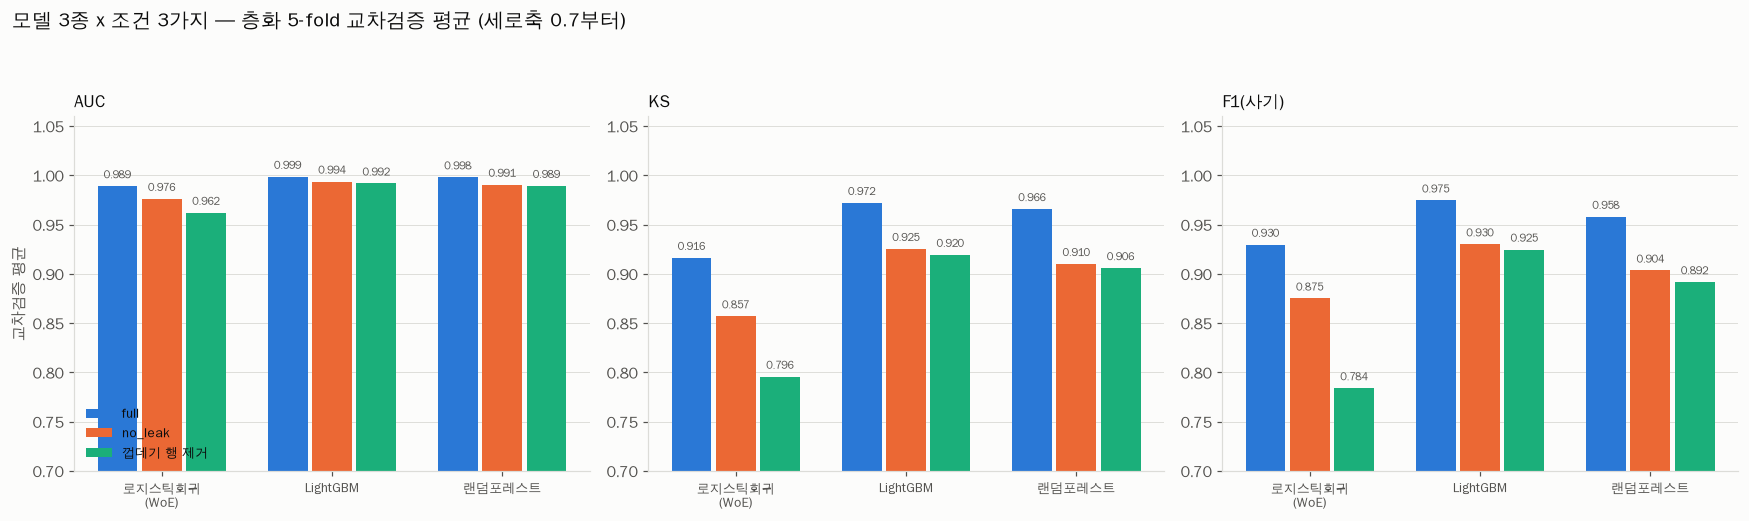

In [8]:
# 세 조건(full / no_leak / 껍데기 행 제거)을 지표별로 나란히 비교한다.
# 형태 선택: '모델 x 조건'의 크기 비교이므로 묶음 막대(grouped bar)가 맞다.
condition_summaries = {
    "full": track_summaries["full"],
    "no_leak": track_summaries["no_leak"],
    "껍데기 행 제거": diagnostic_summary,
}

metrics_to_plot = ["AUC", "KS", "F1(사기)"]
figure, axes = plt.subplots(1, 3, figsize=(16, 4.6))

model_positions = np.arange(len(modeling.ALL_MODEL_NAMES))
bar_width = 0.26

for axis, metric_name in zip(axes, metrics_to_plot):
    for condition_index, (condition_name, summary_table) in enumerate(condition_summaries.items()):
        values = [
            summary_table.set_index("모델").loc[model_name, f"_{metric_name}_평균"]
            for model_name in modeling.ALL_MODEL_NAMES
        ]
        offsets = model_positions + (condition_index - 1) * bar_width

        axis.bar(
            offsets, values, width=bar_width * 0.9,
            color=TRACK_COLORS[condition_name],
            label=condition_name if metric_name == "AUC" else None,
        )
        # 색만으로 구분되지 않도록 막대 위에 숫자를 직접 붙인다
        for offset, value in zip(offsets, values):
            axis.text(offset, value + 0.008, f"{value:.3f}",
                      ha="center", fontsize=7, color=COLOR_TEXT_SECONDARY)

    axis.set_xticks(model_positions)
    axis.set_xticklabels([name.replace(" ", "\n") for name in modeling.ALL_MODEL_NAMES], fontsize=8.5)
    axis.set_title(metric_name, loc="left", fontsize=11)
    axis.set_ylim(0.7, 1.06)
    axis.grid(axis="x", visible=False)

axes[0].set_ylabel("교차검증 평균")
axes[0].legend(loc="lower left", fontsize=8.5)

figure.suptitle(
    "모델 3종 x 조건 3가지 — 층화 5-fold 교차검증 평균 (세로축 0.7부터)",
    fontsize=13, x=0.01, ha="left", y=1.02,
)
figure.tight_layout(rect=[0, 0, 1, 0.96])
figure.savefig(config.FIGURES_DIRECTORY / "04_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

findfont: Failed to find font weight normal, now using 500.


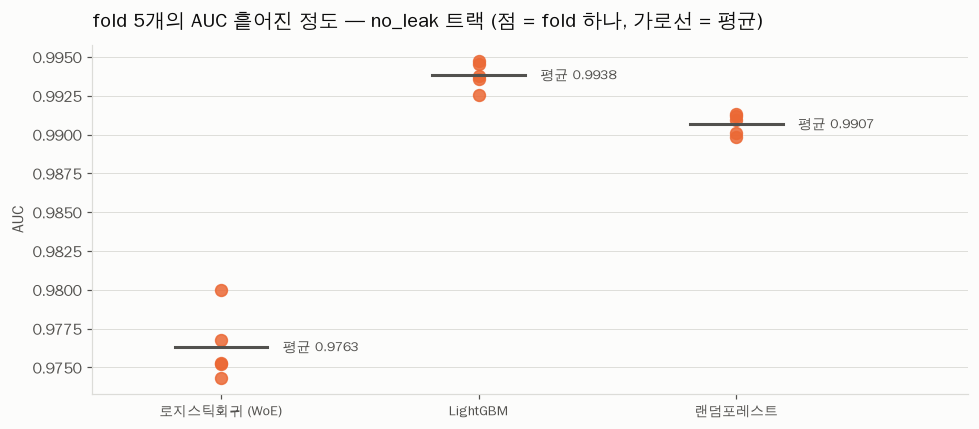

In [9]:
# fold 별 편차도 확인한다. 평균이 같아도 들쭉날쭉하면 신뢰하기 어렵다.
fold_detail_no_leak = track_details["no_leak"]

# 색은 'no_leak 트랙' 하나만 뜻하므로 모든 점을 같은 색으로 칠한다.
# (앞 그림에서 색은 '트랙'을 뜻했다. 같은 색이 그림마다 다른 뜻이면 오해를 부른다.
#  모델 구분은 가로축 이름표가 이미 해 주므로 색을 나눌 이유가 없다.)
figure, axis = plt.subplots(figsize=(9, 4))
for model_index, model_name in enumerate(modeling.ALL_MODEL_NAMES):
    model_folds = fold_detail_no_leak[fold_detail_no_leak["모델"] == model_name]
    axis.scatter(
        [model_index] * len(model_folds), model_folds["AUC"],
        s=60, color=TRACK_COLORS["no_leak"], zorder=3, alpha=0.85,
    )
    mean_auc = model_folds["AUC"].mean()
    axis.plot([model_index - 0.18, model_index + 0.18], [mean_auc, mean_auc],
              color="#52514e", linewidth=2, zorder=4)
    axis.text(model_index + 0.24, mean_auc, f"평균 {mean_auc:.4f}",
              va="center", fontsize=9, color=COLOR_TEXT_SECONDARY)

axis.set_xticks(range(len(modeling.ALL_MODEL_NAMES)))
axis.set_xticklabels(modeling.ALL_MODEL_NAMES, fontsize=9)
axis.set_ylabel("AUC")
axis.set_xlim(-0.5, len(modeling.ALL_MODEL_NAMES) - 0.1)
axis.set_title("fold 5개의 AUC 흩어진 정도 — no_leak 트랙 (점 = fold 하나, 가로선 = 평균)",
              loc="left", pad=12)
axis.grid(axis="x", visible=False)

figure.tight_layout()
figure.savefig(config.FIGURES_DIRECTORY / "05_fold_variation.png", dpi=150, bbox_inches="tight")
plt.show()

---

## 6. 보고서 저장

In [10]:
lines = ["# 모델 3종 성능 비교", ""]
lines.append("층화 5-fold 교차검증 결과입니다. 값은 **fold 5개의 평균 ± 표준편차**입니다.")
lines.append("")
lines.append(f"- 난수 시드: `{config.RANDOM_SEED}` (같은 시드로 돌리면 같은 결과가 나옵니다)")
lines.append(f"- 판정 임계값: `{modeling.DEFAULT_DECISION_THRESHOLD}` (단계 6에서 비용에 맞게 다시 고릅니다)")
lines.append("- 클래스 가중치: 사용하지 않음 (단계 6의 비용 기반 임계값 분석을 위해 확률값을 보존)")
lines.append("")
lines.append("> ## ⚠️ 이 표의 숫자를 그대로 믿으면 안 됩니다")
lines.append("> ")
lines.append("> 아래 AUC(0.97~0.999)와 KS(0.86~0.97)는 **현실의 사기 탐지 모형에서 나올 수 없는 값**입니다.")
lines.append("> 실무에서는 AUC 0.75~0.85, KS 0.30~0.50 정도가 좋은 모형입니다.")
lines.append("> 이 데이터셋은 정상 주소와 사기 주소를 서로 다른 방식으로 수집해 합쳤기 때문에,")
lines.append("> 두 집단이 거의 모든 특징에서 체계적으로 다릅니다.")
lines.append("> 자세한 근거는 `reports/iv_ranking.md` 와 `notebooks/02_woe_iv.ipynb` 를 보세요.")
lines.append("")
lines.append("---")
lines.append("")

for track_label, description in [
    ("full", "누수 포함 (39개 특징) — `ERC20 이력 없음(표시)` 열을 특징으로 사용"),
    ("no_leak", "누수 최소 차단 (38개 특징) — 표시 열 없음, ERC20 결측을 0으로 채움"),
]:
    lines.append(f"## 트랙 `{track_label}` — {description}")
    lines.append("")
    lines.append(track_summaries[track_label][["모델"] + METRIC_COLUMNS].to_markdown(index=False))
    lines.append("")

lines.append("## 두 트랙의 차이 — 누수가 성능을 부풀린 정도")
lines.append("")
lines.append(track_difference_table.to_markdown(index=False))
lines.append("")
lines.append("---")
lines.append("")
lines.append("## 진단 A — 껍데기 행 274개 제거 후")
lines.append("")
lines.append("모든 특징이 0인데 100% 사기인 행 274개를 빼고 다시 돌린 결과입니다.")
lines.append("")
lines.append(diagnostic_summary[["모델"] + METRIC_COLUMNS].to_markdown(index=False))
lines.append("")
lines.append("**해석**: LightGBM 의 AUC 가 여전히 0.99 입니다. 이 274개 행은 주범이 아니며,")
lines.append("오염이 훨씬 넓게 퍼져 있다는 뜻입니다.")
lines.append("")
lines.append("---")
lines.append("")
lines.append("## 진단 B — 대조군 실험 (파이프라인 검증)")
lines.append("")
lines.append("정답(FLAG)을 무작위로 섞어서 학습시켰습니다. 특징과 정답의 관계가 완전히 끊어졌으므로,")
lines.append("코드가 올바르다면 AUC 가 0.5 근처로 나와야 합니다.")
lines.append("")
lines.append(control_summary[["모델"] + METRIC_COLUMNS].to_markdown(index=False))
lines.append("")
lines.append(f"**결과: AUC = {control_auc:.4f}** → 0.5 에 가까우므로 교차검증 파이프라인은 올바릅니다.")
lines.append("높은 성능은 코드 버그가 아니라 **데이터 자체의 성질**입니다.")
lines.append("")
lines.append("---")
lines.append("")
lines.append("## fold 별 상세 (no_leak 트랙)")
lines.append("")
lines.append(track_details["no_leak"].round(4).to_markdown(index=False))
lines.append("")

output_path = config.REPORTS_DIRECTORY / "model_comparison.md"
output_path.write_text("\n".join(lines), encoding="utf-8")
print(f"저장 완료: {output_path}")

저장 완료: /home/user/blockchain/reports/model_comparison.md


---

## 7. 단계 4 요약

**모델 순위** (세 조건 모두에서 동일): LightGBM > 랜덤포레스트 > 로지스틱회귀(WoE)

- **LightGBM** 이 모든 지표에서 1위입니다. 트리를 순차적으로 쌓으며 이전 트리의
  실수를 보완하는 방식이라, 복잡한 경계도 잘 잡아냅니다.
- **로지스틱회귀(WoE)** 는 성능이 가장 낮지만 격차가 크지 않고,
  **계수를 그대로 해석할 수 있다**는 장점이 있습니다. 실무에서 규제 대응이 필요한
  신용평가 모형에 로지스틱회귀를 쓰는 이유입니다.
- fold 간 표준편차가 모두 0.01 이하로 작아, 결과 자체는 **안정적**입니다.

**누수의 영향**: full → no_leak 로 바꾸면 KS 가 0.05~0.06 떨어집니다.
표시 열 **하나**를 뺐을 뿐인데 이 정도 차이가 납니다.

**그러나 가장 중요한 결론은 따로 있습니다:**

> 대조군 실험(AUC 0.49)으로 **파이프라인은 정상**임을 확인했습니다.
> 그럼에도 AUC 0.99가 나온다는 것은, 이 데이터셋으로는
> **"현실에서 쓸 수 있는 사기 탐지 모델"을 만들 수 없다**는 뜻입니다.
> 앞으로의 단계(5·6)는 **방법론을 익히는 연습**으로 진행하며,
> 성능 숫자는 참고용으로만 봅니다.

**다음 단계(5)**: LightGBM 에 SHAP 을 적용해 "모델이 실제로 무엇을 보고 판단했는지"를
확인합니다. 모델이 누수 신호에 의존하고 있다면 SHAP 그림에 그대로 드러날 것입니다.